In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy, csv
import os, sys
import neurokit2 as nk
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))  # Add parent directory to sys.path
from datetime import datetime, timezone
from scipy.signal import resample, butter, filtfilt, find_peaks, hilbert, savgol_filter
from export_AF_Bed import *
from bed_info import *
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('default')  # Use default style for better visibility of gridlines

In [90]:
def convert_mindray_n15_csv_to_resampled_npy(
    csv_path: str,
    fs_in: int = 500,
    fs_out: int = 100
):

    ecg_all = []
    ts_all = []

    dt_per_sample_ns = int(1e9 / fs_in)  # 原始采样点间隔

    # -------------------------
    # Step 1: 读原始 CSV
    # -------------------------
    with open(csv_path, "r", encoding="utf-8-sig") as f:
        reader = csv.reader(f)

        for row_idx, row in enumerate(reader):
            if not row:
                continue

            base_time_str = row[0].strip()

            try:
                base_time = pd.to_datetime(base_time_str)
            except Exception as e:
                raise ValueError(
                    f"第 {row_idx + 1} 行时间解析失败: {base_time_str}"
                ) from e

            sample_strs = row[1:]

            if len(sample_strs) != fs_in:
                raise ValueError(
                    f"第 {row_idx + 1} 行样本数不是 {fs_in}，而是 {len(sample_strs)}"
                )

            try:
                samples = np.array(sample_strs, dtype=np.float32)
            except Exception as e:
                raise ValueError(
                    f"第 {row_idx + 1} 行 ECG 数据转换失败"
                ) from e

            base_ns = np.datetime64(base_time.to_datetime64(), "ns")
            offsets = np.arange(fs_in, dtype=np.int64) * dt_per_sample_ns
            timestamps = base_ns + offsets.astype("timedelta64[ns]")

            ecg_all.append(samples)
            ts_all.append(timestamps)

    ecg = np.concatenate(ecg_all, axis=0)  # (N,)
    timestamps = np.concatenate(ts_all, axis=0)  # datetime64[ns], (N,)

    timestamps_resampled_ns, ecg_resampled = resample_with_timestamps(timestamps, ecg, target_fs=100)  # 测试函数是否正常运行
    return ecg_resampled, timestamps_resampled_ns
    # return ecg, timestamps


def clean_resampled_ecg_npy(
    data: np.ndarray,
    fs: int = 100,
    method: str = "neurokit"
):
    """
    读取 [timestamp_ns, ecg] 的 stacked npy，
    用 neurokit2 对 ECG 做去噪/清洗，并进一步去趋势，
    最后保存成新的 stacked npy。

    Parameters
    ----------
    input_path : str
        输入的 stacked npy 文件路径
    output_path : str
        输出的 cleaned stacked npy 文件路径
    fs : int
        采样率，默认 100 Hz
    method : str
        nk.ecg_clean 的方法，默认 "neurokit"
        可选如: "neurokit", "biosppy", "pantompkins1985", "hamilton2002", ...

    Returns
    -------
    cleaned_stacked : np.ndarray
        shape = (N, 2)
        [:, 0] = timestamp_ns
        [:, 1] = cleaned_ecg
    """

    # -------------------------
    # Step 1: 读取数据
    # -------------------------

    if data.ndim != 2 or data.shape[1] != 2:
        raise ValueError(f"输入数据 shape 应为 (N, 2)，当前为 {data.shape}")

    timestamp_ns = data[:, 0].astype(np.int64)
    ecg = data[:, 1].astype(np.float64)

    # -------------------------
    # Step 2: ECG 清洗（滤波 / 去噪）
    # -------------------------
    ecg_cleaned = nk.ecg_clean(ecg, sampling_rate=fs, method=method)

    # -------------------------
    # Step 3: 去趋势
    # order=1 常用于移除缓慢漂移
    # regularization 更平滑一些，也可换成 "polynomial"
    # -------------------------
    ecg_detrended = nk.signal_detrend(
        ecg_cleaned,
        method="polynomial",
        order=1
    )

    # -------------------------
    # Step 4: stack 保存
    # -------------------------
    cleaned_stacked = np.column_stack([
        timestamp_ns.astype(np.float64),
        ecg_detrended.astype(np.float64)
    ])

    return cleaned_stacked
def find_idx(target_time, timestamps, time_zone="Asia/Shanghai", exact=False):
    # Parse timestamps as timezone-aware UTC for reliable matching.
    ts = pd.to_datetime(timestamps, utc=True)
    
    # Interpret target_time in the provided timezone, then convert to UTC.
    target = pd.to_datetime(target_time)
    if target.tzinfo is None:
        target = target.tz_localize(time_zone)
    else:
        target = target.tz_convert(time_zone)
    target = target.tz_convert("UTC")
    
    if exact:
        matches = (ts == target)
        if matches.any():
            return matches.argmax()   # 第一个匹配位置
        else:
            raise ValueError(f"target_time {target} 不在 timestamps 中")
    else:
        # 找最近的时间点
        diff = abs(ts - target)
        return diff.argmin()
    

def norm_ecg(ECG):
    ECG = (ECG - np.min(ECG)) / (np.max(ECG) - np.min(ECG))
    return ECG
def timestamp_to_seconds(timestamps):
    # Convert ISO 8601 timestamps to seconds since the first timestamp
    base_time = pd.to_datetime(timestamps[0])
    seconds = [(pd.to_datetime(ts) - base_time).total_seconds()
               for ts in timestamps]
    return np.array(seconds)
def butter_bandpass(x, fs, lo=0.5, hi=30.0, order=3):
    b, a = butter(order, [lo, hi], btype='band', fs=fs)
    return filtfilt(b, a, x)

def lowpass(x, fs, fc=0.6, order=3):
    b, a = butter(order, fc, btype='low', fs=fs)
    return filtfilt(b, a, x)

def _butter_bandpass(low, high, fs, order=3):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return b, a
def extract_hilbert_envelope_and_remove(
    x: np.ndarray,
    smooth_win: int | None = None,
    smooth_poly: int = 3,
    remove_method: str = "divide",
    eps: float = 1e-8,
):
    """
    计算 Hilbert 包络，并从原始信号中去除包络。

    参数
    ----
    x : 1D numpy array，信号取值在 [0, 1] 或任意实数范围均可
    smooth_win : 可选，对包络做 Savitzky–Golay 平滑的窗口长度(奇数)。None 表示不平滑
    smooth_poly : Savitzky–Golay 的多项式阶数（通常 2 或 3 即可）
    remove_method : "divide" 或 "subtract"
        - "divide": 按包络幅度进行幅度解调 y = x / (env + eps)
        - "subtract": 直接相减 y = x - env
    eps : 防止除零的微小常数

    返回
    ----
    env : np.ndarray, Hilbert 包络（可选已平滑）
    y   : np.ndarray, 去除包络后的信号
    """
    x = butter_bandpass(x, 100)
    x= np.pad(x, (20,0), 'edge')
    x = np.asarray(x, dtype=float).ravel()

    # 1) Hilbert 分析信号与包络
    analytic = hilbert(x)
    env = np.abs(analytic)

    # 2) 可选：对包络做平滑（建议 smooth_win 为奇数且 >= 5）
    if smooth_win is not None and smooth_win >= 5 and smooth_win % 2 == 1:
        # 若窗口过小或长度超过信号，会自动调整到合适范围
        win = min(smooth_win, len(env) - (1 - len(env) % 2))
        win = max(win, 5 if (5 <= len(env)) else (len(env) | 1))  # 保证奇数
        if win >= 5 and win % 2 == 1 and win <= len(env):
            env = savgol_filter(env, window_length=win, polyorder=min(smooth_poly, win - 2))

    # 3) 去除包络
    remove_method = remove_method.lower()
    if remove_method == "divide":
        # 常用于幅度解调：保留载波/细节，移除慢变幅度
        y = x / (env + eps)
        # 可选：把结果移回零均值或原范围（按需再处理）
        y[20:] = (y[20:] - np.mean(y[20:]))+np.mean(x[20:])  # 如果你希望零均值，可取消注释
    elif remove_method == "subtract":
        # 直接减去包络，得到高频残差（更像去慢趋势）
        y = x - env
    else:
        raise ValueError("remove_method 只能是 'divide' 或 'subtract'。")
    temp = y[20:]
    # rescale to original amplitude
    y[20:] = (temp - np.min(temp)) / (np.max(temp) - np.min(temp)) * (np.max(x[20:]) - np.min(x[20:])) + np.min(x[20:])
    return env[20:], y[20:]
def resample_signal(x, original_fs, target_fs):
    num_samples = int(len(x) * target_fs / original_fs)
    return resample(x, num_samples)


def resample_with_timestamps(timestamps, x, target_fs):
    """
    根据原始时间戳和信号值，重采样到目标采样率

    Parameters
    ----------
    timestamps : array-like
        可被 pandas.to_datetime 解析的时间戳序列
    x : array-like
        对应信号值
    target_fs : float
        目标采样率，例如 100 Hz

    Returns
    -------
    new_timestamps : pd.DatetimeIndex
        重采样后的时间戳
    x_new : np.ndarray
        重采样后的信号
    """
    timestamps = pd.to_datetime(timestamps)
    x = np.asarray(x)

    if len(timestamps) != len(x):
        raise ValueError("timestamps 和 x 长度必须一致")
    sort_idx = np.argsort(timestamps)
    timestamps = timestamps[sort_idx]
    x = x[sort_idx]
    # 转成相对秒
    t0 = timestamps[0]
    t_sec = (timestamps - t0).total_seconds().to_numpy()

    # 生成新的等间隔时间轴
    dt = 1.0 / target_fs
    t_new_sec = np.arange(t_sec[0], t_sec[-1], dt)

    # 线性插值
    x_new = np.interp(t_new_sec, t_sec, x)
    # print(x_new)
    # 生成新的时间戳
    new_timestamps = t0 + pd.to_timedelta(t_new_sec, unit="s")

    return new_timestamps.astype("int64"), x_new


In [91]:
root_path = './data/'
target_path = './data_final/'
fs = 100

In [92]:
def new_struct():
    data_struct = {
        "Info" : {
            "Subject" : None, # -1 means chirp wave, 0-9 means real human subjects
            "Bed_angle" : None, # 0°, 10°,  20°, 30°
            "Posture" : None, # Back, Left side, Right side, Stomach
            "Test" : None, # Post exercise (PE), Cold pressor test (CP), Valsalva (VA)
            "Other_comment" : None,
        },
        # can add bed if needed
        "Bed_ID" : 'AF', # can be: AF, 5, 9, 3, 1, 7, 6, 10, 11, 12, 13, 15
        "BD_up" : None, # BedDot upper sensor, [BSG_x, BSG_y, BSG_z]
        "SCG_z" : None,
        "ECG" : None,
        "ABP" : None,
        "Timestamp" : None,

        # The following items are only used for AF Bed with 3 sets of BedDot
        "BD_compare" : None, # BedDot compare sensor, [BSG_x, BSG_y, BSG_z]
        "BD_mid" : None, # BedDot middle sensor, [BSG_x, BSG_y, BSG_z]
    }
    return data_struct


In [93]:
# selected_bed = bed_AF_ID_30_compare
# selected_bed['SID']
# f'./data/{selected_bed["SID"]}_{status}.npy'

### Info. of the current trial

In [94]:
selected_bed = bed_AF_ID_30_up
# selected_bed = bed_15_ID_15
# status = 'chirp_womat_'
status = 'sub_1_wo_bd_'
status = 'sub_1_PE_'
cur_struct = new_struct()
cur_struct['Bed_ID'] = 'AF'


### Read BedDot data

In [95]:
bed_reading = np.load(f'../data/{selected_bed["SID"]}_{status}.npy', allow_pickle=True).item()
signal_30 = bed_reading['data']
BSG_timestamps = bed_reading['timestamps']
# selected_bed = bed_AF_ID_on
# signal_on = np.load(f'../data/{selected_bed["SID"]}_{status}.npy', allow_pickle=True).item()['data']
if cur_struct['Bed_ID'] == 'AF':
    selected_bed = bed_AF_ID_30_compare
    bed_reading_2 = np.load(f'../data/{selected_bed["SID"]}_{status}.npy', allow_pickle=True).item()
    signal_cp = bed_reading_2['data']
    selected_bed = bed_AF_ID_18_mid
    bed_reading_3 = np.load(f'../data/{selected_bed["SID"]}_{status}.npy', allow_pickle=True).item()
    signal_mid = bed_reading_3['data']
    # cur_struct['BD_compare'] = bed_reading_2['data']
    # cur_struct['BD_mid'] = bed_reading_3['data']

### Read SCG data (need manually time sync)

In [96]:
scg_file = f'../data/device_device1_{status}.npy'
SCG_org_fs = 62
scg_reading = np.load(scg_file, allow_pickle=True)
scg_reading.shape
ts_scg_org = scg_reading[:, 0]
scg_z_org = (scg_reading[:, 3])
true_len_scg = (BSG_timestamps[-1]-BSG_timestamps[0])/1e9 * SCG_org_fs
print(len(scg_reading[:, 3]), true_len_scg) if np.abs(len(scg_reading[:, 3]) - true_len_scg) > 1 else print("SCG length matches expected length based on timestamps.")

ts_scg, scg_z = resample_with_timestamps(ts_scg_org, scg_z_org, target_fs = 100)
# env, scg_z = extract_hilbert_envelope_and_remove(scg_z, smooth_win=101, remove_method="divide")
print(len(signal_30[0]), len(scg_reading[:, 3]),  len(scg_z))

# shanghai timezone is UTC+8, so we need to add 8 hours to the timestamps
dt_scg = pd.to_datetime(ts_scg[0], unit='ns')
dt_bsg = pd.to_datetime(BSG_timestamps[-1], unit='ns') 
print(f"Last timestamp of SCG: {dt_scg}, Last timestamp of BSG: {dt_bsg}")


9188 32116.0
51801 9188 14799
Last timestamp of SCG: 2026-03-17 08:18:00.005000192, Last timestamp of BSG: 2026-03-17 08:25:38


Selected time window: 2026-3-17 16:18:40 to 2026-3-17 16:25:38 
Corresponding to indices 10000 to 11000 in BSG timestamps.


Text(0.5, 1.0, 'BSG vs. SCG')

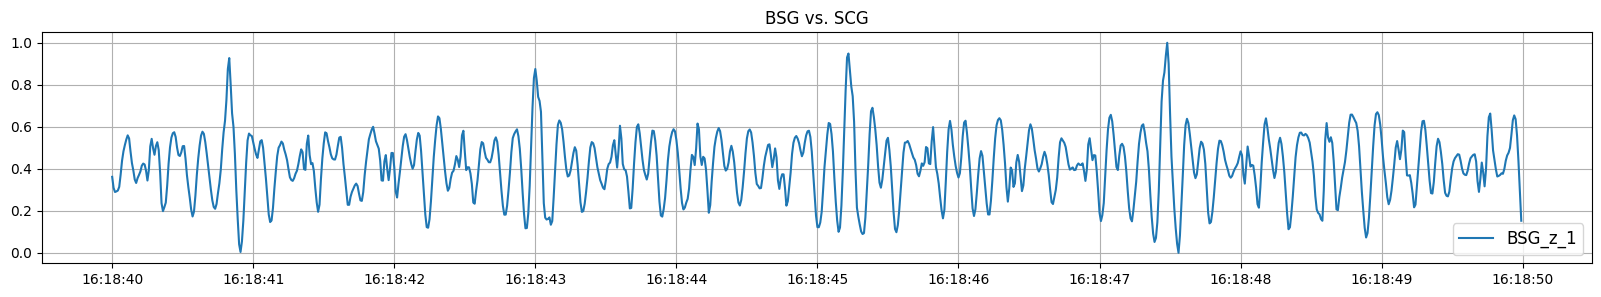

In [97]:
# check the time synchronization between SCG and BSG
start_time = "2026-3-17 16:18:40"
# start_time = "2026-3-16 11:08:00"
end_time = "2026-3-17 16:25:38"
start_bsg = find_idx(start_time, BSG_timestamps, "Asia/Shanghai")
end_bsg = find_idx(end_time, BSG_timestamps, "Asia/Shanghai")
end_bsg = find_idx(end_time, BSG_timestamps, "Asia/Shanghai")
end_bsg = start_bsg + 15500
end_bsg = start_bsg + 1000
# end_scg = start_scg + 1000
print(f"Selected time window: {start_time} to {end_time} \nCorresponding to indices {start_bsg} to {end_bsg} in BSG timestamps.")

# start = 0
# end = start +1000
t = pd.to_datetime(BSG_timestamps) + pd.to_timedelta(8, unit='h')  # 转换为上海时间
t_scg = pd.to_datetime(ts_scg_org) + pd.to_timedelta(8, unit='h')  # 转换为上海时间
plt.figure(figsize=(20, 3))
plt.plot(t[start_bsg:end_bsg], norm_ecg(signal_30[2, start_bsg:end_bsg])+0, label='BSG_z_1')
# plt.plot(t[:], norm_ecg(signal[2, :])+0, label='BSG_z_1')
# plt.plot(t[start_bsg:end_bsg], norm_ecg(signal_on[2, start_bsg:end_bsg])+0., label='BSG_z_on')
shift_scg = int(100*2.32)
# shift = int(fs*2.34)
# plt.plot(t_scg[start_scg:end_scg], norm_ecg(scg_z_org[start_scg+shift_scg:end_scg+shift_scg]), label='SCG_z', alpha=1)
# plt.plot(t[start_bsg:end_bsg], norm_ecg(scg_z[start_bsg+shift_scg:end_bsg+shift_scg]), label='SCG_z', alpha=1)
plt.legend(loc='lower right', fontsize=12, ncol=3)
plt.grid()
plt.title(f'BSG vs. SCG')

In [98]:
# plt.figure(figsize=(20, 3))
# plt.plot(t[start_bsg:end_bsg], norm_ecg(signal_30[0, start_bsg:end_bsg])+0, label='BSG_x_1')
# plt.plot(t[start_bsg:end_bsg], norm_ecg(signal_30[1, start_bsg:end_bsg])+0, label='BSG_y_1')
# plt.plot(t[start_bsg:end_bsg], norm_ecg(signal_30[2, start_bsg:end_bsg])+0, label='BSG_z_1')
# plt.legend(loc='lower right', fontsize=12, ncol=3)
# plt.grid()

### Read ECG

In [99]:


ecg_path = '../data/ECG_data/ECG_II-YY2.csv'

ecg_resampled, date_time = convert_mindray_n15_csv_to_resampled_npy(
    csv_path=ecg_path,
    fs_in=500,
    fs_out=100
)
# cleaned_data = clean_resampled_ecg_npy(
#     data=np.column_stack([date_time.astype(np.float64), ecg_resampled.astype(np.float64)]),
#     fs=100,
#     method="neurokit"
# )


In [100]:
(pd.to_datetime(date_time[-1]) - pd.to_datetime(date_time[0])).total_seconds(), len(ecg_resampled)
# (date_time[-1]-date_time[0]).total_seconds()

(1724.99, 172500)

Selected time window: 2026-3-17 16:21:00 to 2026-3-17 11:01:30 
Corresponding to indices 138900 to 139900 in ECG timestamps.
Estimated heart rate from ECG: 96.93 bpm
96.87184661957619


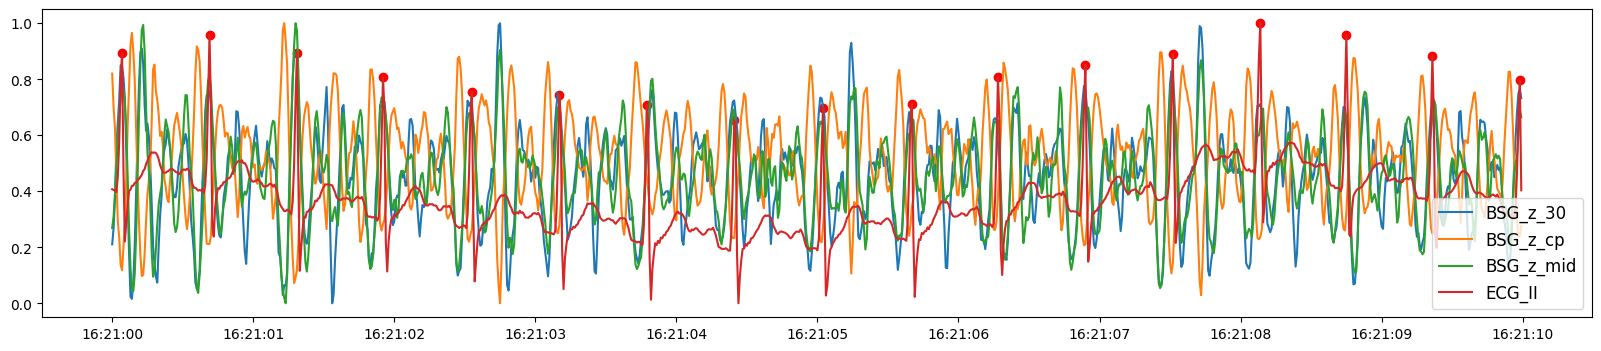

In [141]:
# plot the signal
ecg = ecg_resampled
ecg_ts = pd.to_datetime(date_time.astype(np.int64), unit='ns') - pd.to_timedelta(8, unit='h') 
ecg_t = pd.to_datetime(ecg_ts) + pd.to_timedelta(8, unit='h')    # 转换为上海时间
# ecg_ts = BSG_timestamps
length = 1000
start_time = "2026-3-17 16:21:00"
end_time = "2026-3-17 11:01:30"
start_ecg = find_idx(start_time, ecg_ts, "Asia/Shanghai")
end_ecg = find_idx(end_time, ecg_ts, "Asia/Shanghai")
start_bsg = find_idx(start_time, BSG_timestamps, "Asia/Shanghai")
end_bsg = start_bsg + length
# start = start - 500
end_ecg = start_ecg + length
print(f"Selected time window: {start_time} to {end_time} \nCorresponding to indices {start_ecg} to {end_ecg} in ECG timestamps.")
# shift_time = -0.35
shift_time = 0.24
shift_ecg = int(100*shift_time)
shift_scg = int(100*2.15)
plt.figure(figsize=(20, 4))
plt.plot(t[start_bsg:end_bsg], norm_ecg(signal_30[2, start_bsg:end_bsg])+0, label='BSG_z_30')
plt.plot(t[start_bsg:end_bsg], norm_ecg(signal_cp[2, start_bsg:end_bsg])+0, label='BSG_z_cp')
plt.plot(t[start_bsg:end_bsg], norm_ecg(signal_mid[2, start_bsg:end_bsg])+0, label='BSG_z_mid')
# plt.plot(t[start_bsg:end_bsg], norm_ecg(scg_z[start_bsg+shift_scg:end_bsg+shift_scg]), label='SCG_z', alpha=1)
plt.plot(ecg_t[start_ecg:end_ecg], norm_ecg(ecg[start_ecg+shift_ecg:end_ecg+shift_ecg]), label='ECG_II')
# plt.plot(ecg_t, ecg, label='ECG_II')
# use nk to give HR

plt.legend(loc='lower right', fontsize=12)
signals, info = nk.ecg_process(ecg[start_ecg+shift_ecg:end_ecg+shift_ecg], sampling_rate=fs)
# detect the peak of eag
peaks = find_peaks(ecg[start_ecg+shift_ecg:end_ecg+shift_ecg], distance=fs*0.3, height = 0.5)[0]
plt.scatter(ecg_t[start_ecg:end_ecg][peaks], norm_ecg(ecg[start_ecg+shift_ecg:end_ecg+shift_ecg])[peaks], color='red', label='ECG Peaks')
print(f"Estimated heart rate from ECG: {signals['ECG_Rate'].mean():.2f} bpm")
print(100*60/np.mean(np.diff(peaks)))

In [102]:
ecg[start_ecg+shift_ecg:end_ecg+shift_ecg]

array([  764.        ,   780.        ,   752.        ,   716.        ,
         648.        ,   588.        ,   576.        ,   552.        ,
         560.        ,   564.        ,   588.        ,   580.        ,
         568.        ,   736.        ,  1200.        ,  1868.        ,
        1864.        ,   508.        ,   -68.        ,   196.        ,
         428.00000001,   576.        ,   604.        ,   668.        ,
         688.        ,   740.        ,   780.        ,   844.        ,
         888.        ,   980.        ,  1096.        ,  1216.        ,
        1256.        ,  1252.        ,  1220.        ,  1152.        ,
        1060.        ,   952.        ,   864.        ,   812.        ,
         788.        ,   768.        ,   764.        ,   716.        ,
         664.        ,   624.        ,   608.        ,   608.        ,
         612.        ,   640.        ,   624.        ,   588.        ,
         556.        ,   504.        ,   416.        ,   348.        ,
      

In [103]:
ewrewrd

NameError: name 'ewrewrd' is not defined

### Save struct

In [ ]:
cur_struct['Timestamp'] = BSG_timestamps
cur_struct['BD_up'] = signal_30[:, start_bsg:end_bsg]
cur_struct['SCG_z'] = scg_z[start_bsg+shift_scg:end_bsg+shift_scg]
# cur_struct['ECG'] = ecg[start_ecg+shift_ecg:end_ecg+shift_ecg]
cur_struct['ECG'] = None
if cur_struct['Bed_ID'] == 'AF':
    selected_bed = bed_AF_ID_30_compare
    bed_reading_2 = np.load(f'../data/{selected_bed["SID"]}_{status}.npy', allow_pickle=True).item()
    selected_bed = bed_AF_ID_18_mid
    bed_reading_3 = np.load(f'../data/{selected_bed["SID"]}_{status}.npy', allow_pickle=True).item()
    cur_struct['BD_compare'] = bed_reading_2['data'][:, start_bsg:end_bsg]
    cur_struct['BD_mid'] = bed_reading_3['data'][:, start_bsg:end_bsg]
cur_struct

{'Info': {'Subject': None,
  'Bed_angle': None,
  'Posture': None,
  'Test': None,
  'Other_comment': None},
 'Bed_ID': 'AF',
 'BD_up': array([[  -92963.,   238875.,   555430., ...,  -928949., -1139983.,
          -860026.],
        [  799024.,   283301.,  -372663., ...,   565003.,   171169.,
          -186433.],
        [-1807007., -1027231.,   -21930., ..., -7344733., -8405457.,
         -8054515.]]),
 'SCG_z': array([0.96643556, 0.96369139, 0.96369645, ..., 0.98027335, 0.97734126,
        0.93902829]),
 'ECG': None,
 'ABP': None,
 'Timestamp': array([1773630310000000000, 1773630310010000000, 1773630310020000000, ...,
        1773630507980000000, 1773630507990000000, 1773630508000000000]),
 'BD_compare': array([[  110209.,  -648279., -1312709., ...,   638601.,   501825.,
           416203.],
        [ -113606.,  -110432.,   -81169., ...,   -40461.,   -40873.,
           -21577.],
        [ 1885612.,   867118.,  -312736., ...,  3732112.,  3323166.,
          2290774.]]),
 'BD_mid': ar

In [ ]:
exp = 'bed_angle'
cur_struct['Info']['Subject'] = 3
cur_struct['Info']['Bed_angle'] = 15
cur_struct['Info']['Posture'] = 'Back'
cur_struct['Info']['Test'] = 'Normal'
cur_struct['Info']['Other_comment'] = None
np.save(f'../data_final/{exp}/bed_{cur_struct["Bed_ID"]}_sub_{cur_struct["Info"]["Subject"]}_angle_{cur_struct["Info"]["Bed_angle"]}_.npy', cur_struct)

In [ ]:
sdjfasouidhfos

NameError: name 'sdjfasouidhfos' is not defined

In [ ]:
status = 'test'
bed_reading = np.load(f'../data/bed_AF_ID_30_compare_{status}.npy', allow_pickle=True).item()
bed_reading_2 = np.load(f'../data/bed_AF_ID_30_up_{status}.npy', allow_pickle=True).item()
bed_reading_3 = np.load(f'../data/bed_AF_ID_18_mid_{status}.npy', allow_pickle=True).item()
signal = bed_reading['data']
signal_2 = bed_reading_2['data']
signal_3 = bed_reading_3['data']
timestamps = bed_reading['timestamps']



file_name = f'../data/device_device1_{status}.npy'
scg_reading = np.load(file_name, allow_pickle=True)
scg_reading.shape
ts_scg = scg_reading[:, 0]
# scg_z = (scg_reading[:, 3])
# true_len_scg = (timestamps[-1]-timestamps[0])/1e9*62
# print(len(scg_reading[:, 3]), true_len_scg)

# ts_scg, scg_z = resample_with_timestamps(ts_scg, scg_z, target_fs = 100)
# # env, scg_z = extract_hilbert_envelope_and_remove(scg_z, smooth_win=101, remove_method="divide")
# print(len(signal_2[0]), len(scg_reading[:, 3]), len(ts_scg), len(scg_z))

# # shanghai timezone is UTC+8, so we need to add 8 hours to the timestamps
# dt_scg = pd.to_datetime(ts_scg[-1], unit='ns')
# dt_bsg = pd.to_datetime(timestamps[-1], unit='ns')
# print(f"Last timestamp of SCG: {dt_scg}, Last timestamp of BSG: {dt_bsg}")
# idx = find_idx("2026-3-12 13:57:00", timestamps, "Asia/Shanghai")
# print(idx)
# # time_gap = min((dt_bsg-dt_scg).total_seconds(), (dt_scg-dt_bsg).total_seconds())
# # time_gap*100

In [ ]:
pd.to_datetime(ts_scg[21600:22500], unit='ns')

DatetimeIndex([   '2026-03-12 05:59:21.016000',
                  '2026-03-12 05:59:21.032000',
                  '2026-03-12 05:59:21.048000',
                  '2026-03-12 05:59:21.064000',
                  '2026-03-12 05:59:21.080000',
                  '2026-03-12 05:59:21.096000',
                  '2026-03-12 05:59:21.112000',
                  '2026-03-12 05:59:21.128000',
                  '2026-03-12 05:59:21.144000',
                  '2026-03-12 05:59:21.160000',
               ...
               '2026-03-12 05:59:40.181999872',
               '2026-03-12 05:59:40.197999872',
               '2026-03-12 05:59:40.213999872',
               '2026-03-12 05:59:40.230000128',
               '2026-03-12 05:59:40.246000128',
               '2026-03-12 05:59:40.262000128',
               '2026-03-12 05:59:40.278000128',
               '2026-03-12 05:59:40.293999872',
               '2026-03-12 05:59:40.309999872',
               '2026-03-12 05:59:40.325999872'],
              dtype=

Text(0.5, 1.0, 'BSG vs. SCG')

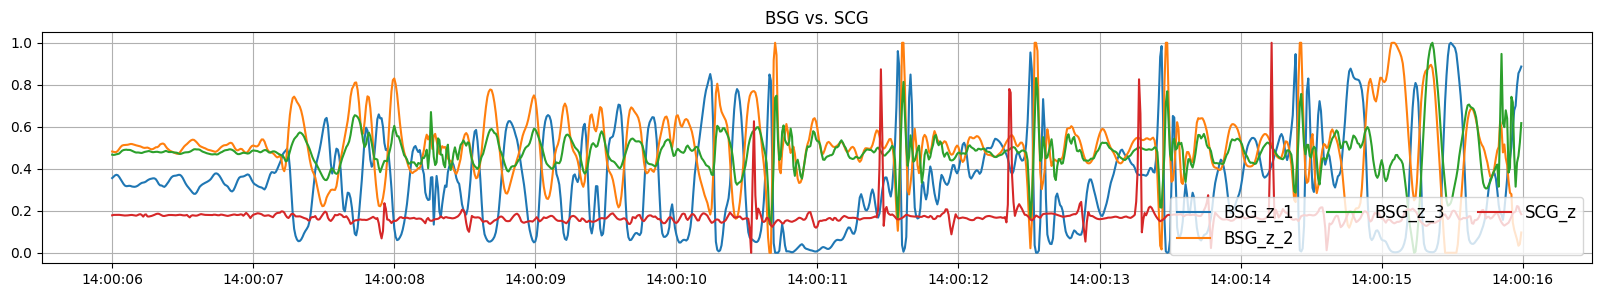

In [ ]:
start = 400
start = 8300
start = 13700
start = 24500
start = 33500
start = 39300
# start = 2500
end = start + 1000
# Reshape from (axis, chunk, simple) to (axis, signals) for easier plotting

t = pd.to_datetime(timestamps[start:end]) + pd.to_timedelta(8, unit='h')  # 转换为上海时间
t_scg = pd.to_datetime(ts_scg) + pd.to_timedelta(8, unit='h')  # 转换为上海时间
plt.figure(figsize=(20, 3))
plt.plot(t, norm_ecg(signal[2, start:end])+0, label='BSG_z_1')
plt.plot(t,norm_ecg(signal_2[2, start:end])+0, label='BSG_z_2')
plt.plot(t,norm_ecg(signal_3[2, start:end])+0, label='BSG_z_3')
shift = int(100*2.33)
plt.plot(t_scg[start:end], norm_ecg(scg_z[start+shift:end+shift]), label='SCG_z', alpha=1)
plt.legend(loc='lower right', fontsize=12, ncol=3)
plt.grid()
plt.title(f'BSG vs. SCG')

In [ ]:
# read from the original data files
# Key words
cur_trial = 1
sub = 1
selected_bed = bed_AF_ID_30_compare

In [ ]:
tt = date_time.astype("int64") // 10**6
pd.to_datetime(tt[0], unit='ns'), pd.to_datetime(tt[-1], unit='ns')

(Timestamp('1970-01-01 00:29:33.340600'),
 Timestamp('1970-01-01 00:29:33.340976990'))

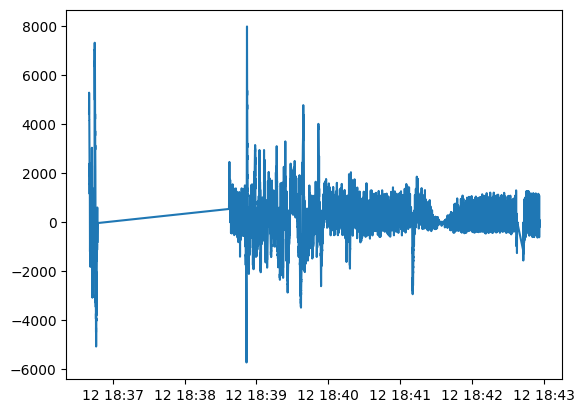

In [ ]:
plt.plot(timestamps, ecg_resampled)

In [ ]:

import neurokit2 as nk
def clean_resampled_ecg_npy(
    input_path: str = "ecg_100hz_stacked.npy",
    output_path: str = "ecg_100hz_cleaned_stacked.npy",
    fs: int = 100,
    method: str = "neurokit"
):
    """
    读取 [timestamp_ns, ecg] 的 stacked npy，
    用 neurokit2 对 ECG 做去噪/清洗，并进一步去趋势，
    最后保存成新的 stacked npy。

    Parameters
    ----------
    input_path : str
        输入的 stacked npy 文件路径
    output_path : str
        输出的 cleaned stacked npy 文件路径
    fs : int
        采样率，默认 100 Hz
    method : str
        nk.ecg_clean 的方法，默认 "neurokit"
        可选如: "neurokit", "biosppy", "pantompkins1985", "hamilton2002", ...

    Returns
    -------
    cleaned_stacked : np.ndarray
        shape = (N, 2)
        [:, 0] = timestamp_ns
        [:, 1] = cleaned_ecg
    """

    # -------------------------
    # Step 1: 读取数据
    # -------------------------
    data = np.load(input_path)

    if data.ndim != 2 or data.shape[1] != 2:
        raise ValueError(f"输入数据 shape 应为 (N, 2)，当前为 {data.shape}")

    timestamp_ns = data[:, 0].astype(np.int64)
    ecg = data[:, 1].astype(np.float64)

    # -------------------------
    # Step 2: ECG 清洗（滤波 / 去噪）
    # -------------------------
    ecg_cleaned = nk.ecg_clean(ecg, sampling_rate=fs, method=method)

    # -------------------------
    # Step 3: 去趋势
    # order=1 常用于移除缓慢漂移
    # regularization 更平滑一些，也可换成 "polynomial"
    # -------------------------
    ecg_detrended = nk.signal_detrend(
        ecg_cleaned,
        method="polynomial",
        order=1
    )

    # -------------------------
    # Step 4: stack 保存
    # -------------------------
    cleaned_stacked = np.column_stack([
        timestamp_ns.astype(np.float64),
        ecg_detrended.astype(np.float64)
    ])

    np.save(output_path, cleaned_stacked)

    # 打印一些信息
    timestamps = pd.to_datetime(timestamp_ns)
    print(f"Input file: {input_path}")
    print(f"Output file: {output_path}")
    print(f"Shape: {cleaned_stacked.shape}")
    print(f"Start time: {timestamps.iloc[0] if hasattr(timestamps, 'iloc') else timestamps[0]}")
    print(f"End time:   {timestamps.iloc[-1] if hasattr(timestamps, 'iloc') else timestamps[-1]}")
    print(f"ECG mean before: {np.mean(ecg):.6f}")
    print(f"ECG std before:  {np.std(ecg):.6f}")
    print(f"ECG mean after:  {np.mean(ecg_detrended):.6f}")
    print(f"ECG std after:   {np.std(ecg_detrended):.6f}")

    return cleaned_stacked



cleaned_data = clean_resampled_ecg_npy(
    input_path="ecg_100hz_stacked.npy",
    output_path="ecg_100hz_cleaned_stacked.npy",
    fs=100,
    method="neurokit"
)

Input file: ecg_100hz_stacked.npy
Output file: ecg_100hz_cleaned_stacked.npy
Shape: (26200, 2)
Start time: 2026-03-12 18:36:40
End time:   2026-03-12 18:41:01.990000128
ECG mean before: 1.569593
ECG std before:  830.494206
ECG mean after:  0.000000
ECG std after:   421.468242


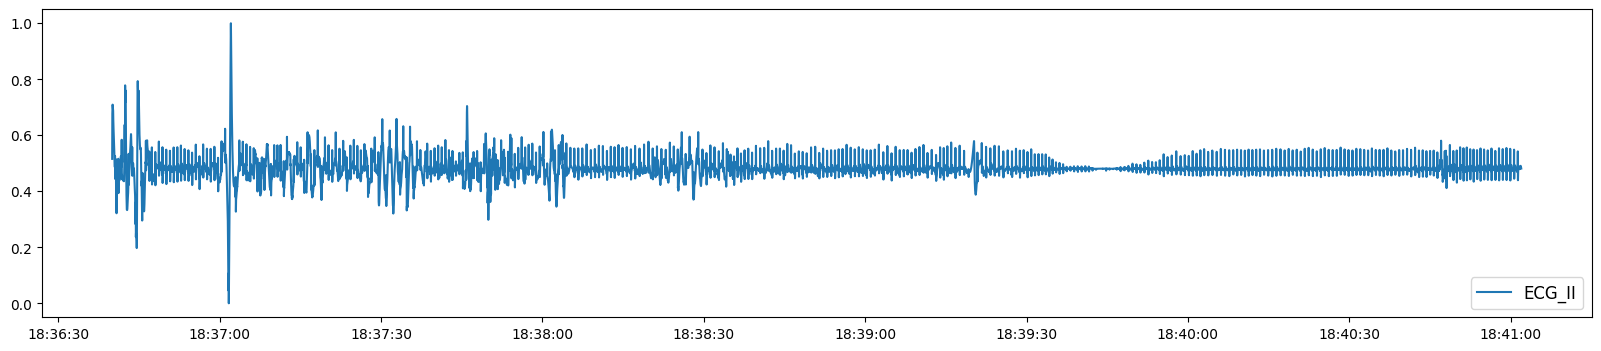

In [ ]:
# plot the signal
ecg = stacked[:, 1]
timestamps = pd.to_datetime(stacked[:, 0].astype(np.int64), unit='ns')
plt.figure(figsize=(20, 4))
plt.plot(timestamps[:], norm_ecg(ecg[:]), label='ECG_II')
plt.legend(loc='lower right', fontsize=12)